In [1]:
import numpy as np
import pandas as pd

# import dataset
df = pd.read_csv('./data/manufacturing_quality_svm.csv', header=0)

# inspect data
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   batch_id                   1600 non-null   str    
 1   temperature_c              1600 non-null   float64
 2   pressure_kpa               1600 non-null   float64
 3   cycle_time_sec             1600 non-null   float64
 4   material_humidity_pct      1600 non-null   float64
 5   operator_experience_years  1600 non-null   float64
 6   machine_age_years          1600 non-null   float64
 7   shift_hours_into_day       1600 non-null   float64
 8   vibration_mm_s             1600 non-null   float64
 9   power_consumption_kwh      1600 non-null   float64
 10  defect_flag                1600 non-null   int64  
dtypes: float64(9), int64(1), str(1)
memory usage: 147.0 KB


,batch_id,temperature_c,pressure_kpa,cycle_time_sec,material_humidity_pct,operator_experience_years,machine_age_years,shift_hours_into_day,vibration_mm_s,power_consumption_kwh,defect_flag
0,B00001,187.0,97.7,105.5,4.15,17.4,13.7,22.0,3.31,76.4,0
1,B00002,198.8,105.3,128.3,7.76,17.4,12.9,21.6,0.61,63.6,0
2,B00003,204.2,162.6,67.0,8.16,13.1,13.9,18.9,2.60,41.1,0
3,B00004,239.5,152.7,63.2,7.90,7.4,7.8,21.9,5.35,36.8,1
4,B00005,210.1,114.6,120.6,7.78,14.2,6.9,6.8,1.29,34.5,0


In [2]:
# Features and target
X = df.drop(columns=['batch_id', 'defect_flag'])
y = df['defect_flag']

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
# scaller
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# train
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

C:\Users\S13350\AppData\Local\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [6]:
# evaluate model
from sklearn.metrics import classification_report

y_pred = svm_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.81      0.76       193
           1       0.65      0.54      0.59       127

    accuracy                           0.70       320
   macro avg       0.69      0.67      0.68       320
weighted avg       0.69      0.70      0.69       320



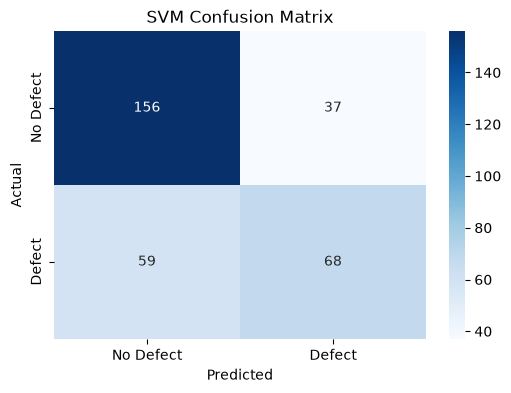

In [7]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Defect','Defect'],
    yticklabels=['No Defect','Defect']
)

plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

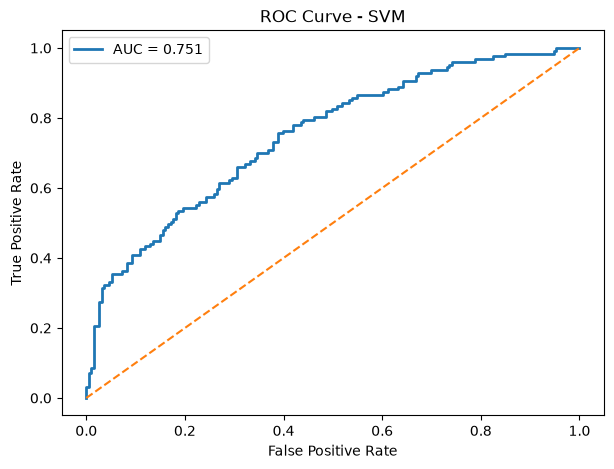

In [8]:
# roc curve
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = svm_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc:.3f}',
    linewidth=2
)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend()

plt.show()

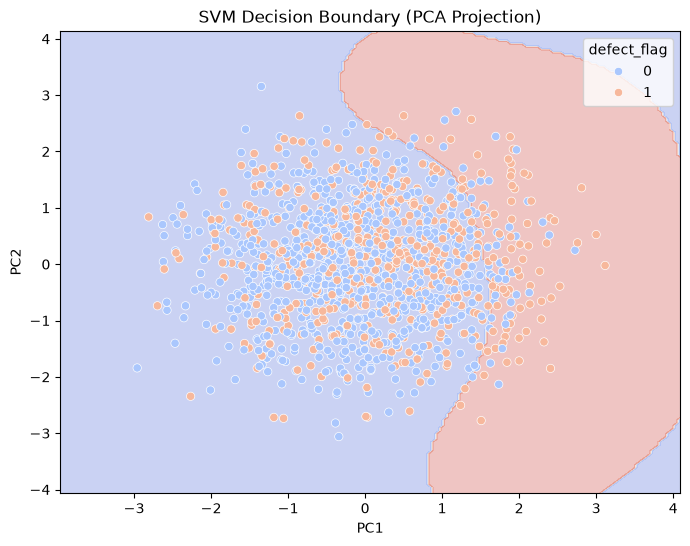

In [9]:
# decision boundary
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import numpy as np

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

svm_2d = SVC(kernel='rbf')
svm_2d.fit(X_pca, y_train)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap='coolwarm'
)

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y_train,
    palette='coolwarm'
)

plt.title('SVM Decision Boundary (PCA Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()
